In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))
df

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [16]:
min_vals = np.min(features, axis=0)
max_vals = np.max(features, axis=0)
features_norm = (features - min_vals) / (max_vals - min_vals)
n_values = np.max(labels) + 1
labels_onehot = np.eye(n_values)[labels]
labels_onehot.shape

(150, 3)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(features_norm, labels, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [19]:
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 10)   # 4 input features -> 10 skjulte noder
        self.fc2 = nn.Linear(10, 3)   # 10 skjulte noder -> 3 output-klasser
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = IrisNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

losses = []
num_epochs = 100

for epoch in range(num_epochs):
    # 1. Nullstill gradientene fra forrige runde
    optimizer.zero_grad()
    
    # 2. Forward pass - kjør data gjennom nettverket
    outputs = model(X_train_tensor)

    # 3. Regn ut loss
    loss = loss_fn(outputs, y_train_tensor)
    
    # 4. Backward pass - regn ut gradienter
    loss.backward()
    
    # 5. Oppdater vektene
    optimizer.step()
    
    # 6. Lagre loss for senere plotting
    losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.0793
Epoch 10, Loss: 0.3668
Epoch 20, Loss: 0.1540
Epoch 30, Loss: 0.0910
Epoch 40, Loss: 0.0647
Epoch 50, Loss: 0.0588
Epoch 60, Loss: 0.0560
Epoch 70, Loss: 0.0535
Epoch 80, Loss: 0.0522
Epoch 90, Loss: 0.0511


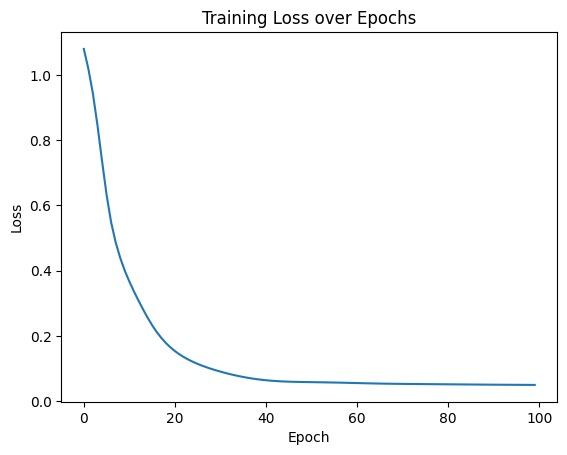

In [20]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

In [21]:
X_all_tensor = torch.tensor(features_norm, dtype=torch.float32)
y_all_tensor = torch.tensor(labels, dtype=torch.long)

model.eval()
with torch.no_grad():
    all_outputs = model(X_all_tensor)
    predicted_all = torch.argmax(all_outputs, dim=1)
    accuracy_all = (predicted_all == y_all_tensor).float().mean()
    print(f"Accuracy på hele datasettet: {accuracy_all.item():.4f}")

Accuracy på hele datasettet: 0.9867
